In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from wordcloud import WordCloud, STOPWORDS
import string
import re

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

load data

In [4]:
d=pd.read_csv("amazon_alexa.tsv" , delimiter = '\t', quoting=3)

In [5]:
d

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1
...,...,...,...,...,...
3145,5,30-Jul-18,Black Dot,"""Perfect for kids, adults and everyone in betw...",1
3146,5,30-Jul-18,Black Dot,"""Listening to music, searching locations, chec...",1
3147,5,30-Jul-18,Black Dot,"""I do love these things, i have them running m...",1
3148,5,30-Jul-18,White Dot,"""Only complaint I have is that the sound quali...",1


In [6]:
d.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [7]:
d.shape

(3150, 5)

In [8]:
d.columns

Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='object')

In [9]:
d1= d[['verified_reviews', 'rating']]
d1.head()

,verified_reviews,rating
0,Love my Echo!,5
1,Loved it!,5
2,"""Sometimes while playing a game, you can answe...",4
3,"""I have had a lot of fun with this thing. My 4...",5
4,Music,5


count of each rating

In [10]:
d1.rating.value_counts()

rating
5    2286
4     455
1     161
3     152
2      96
Name: count, dtype: int64

<Axes: ylabel='rating'>

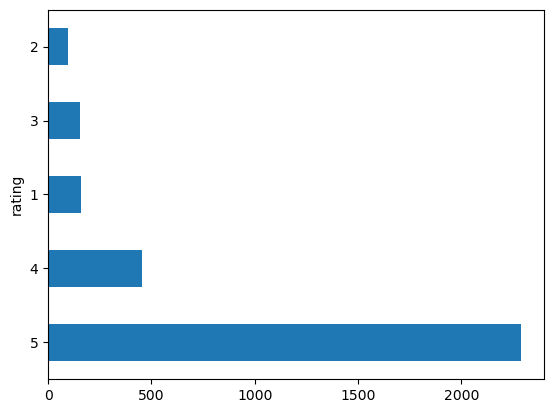

In [11]:
d1.rating.value_counts().plot(kind= 'barh')

check missing values

In [12]:
d1.isnull().sum()

verified_reviews    1
rating              0
dtype: int64

In [13]:
d1[d1.duplicated()]

,verified_reviews,rating
151,Love it,5
219,,5
220,Cool,5
273,Love it!,5
323,Great,5
...,...,...
3145,"""Perfect for kids, adults and everyone in betw...",5
3146,"""Listening to music, searching locations, chec...",5
3147,"""I do love these things, i have them running m...",5
3148,"""Only complaint I have is that the sound quali...",5


drop duplicates

In [14]:
d2=d1.drop_duplicates()

In [15]:
d2.shape

(2315, 2)

In [16]:
d2.rating.value_counts()

rating
5    1661
4     339
1     130
3     107
2      78
Name: count, dtype: int64

In [17]:
def map_feedback(x):
    if x<3:
        return 'Negative'
    elif x==3:
         return 'Neutral'
    else:
        return 'Positive'

In [18]:
d2['feedback'] = d2['rating'].apply(lambda x : map_feedback(x))

C:\Users\hp\AppData\Local\Temp\ipykernel_18584\2772806487.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2['feedback'] = d2['rating'].apply(lambda x : map_feedback(x))


In [19]:
d2.head()

,verified_reviews,rating,feedback
0,Love my Echo!,5,Positive
1,Loved it!,5,Positive
2,"""Sometimes while playing a game, you can answe...",4,Positive
3,"""I have had a lot of fun with this thing. My 4...",5,Positive
4,Music,5,Positive


In [20]:
d2.feedback.value_counts()

feedback
Positive    2000
Negative     208
Neutral      107
Name: count, dtype: int64

text cleaning and preprocessing

In [21]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')  # run once

stopword = stopwords.words('english')
print(stopword[:10])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
#stopwords
total_stopwords = set(stopwords.words('english'))

negative_stop_words = {"no", "not", "nor"}

# final stopwords (remove negative words)
final_stopwords = total_stopwords - negative_stop_words

print("Total stopwords:", len(total_stopwords))
print("Negative stopwords:", negative_stop_words)
print("Final stopwords:", len(final_stopwords))

Total stopwords: 198
Negative stopwords: {'not', 'no', 'nor'}
Final stopwords: 195


In [23]:
#stemming object
stemmer = PorterStemmer()

HTMLTAGS = re.compile('<.*?>')
table = str.maketrans('', '', string.punctuation)
remove_digits = str.maketrans('', '', string.digits)
MULTIPLE_WHITESPACE = re.compile(r"\s+")

In [24]:
def TEXT_PREPROCESSOR(feedback):

    #  1. lower case FIRST
    feedback = feedback.lower()

    #  2. handle negation BEFORE removing punctuation
    feedback = feedback.replace("n't", " not")

    # remove html tags
    feedback = HTMLTAGS.sub(r'', feedback)

    # remove punctuation
    feedback = feedback.translate(table)

    # remove digits
    feedback = feedback.translate(remove_digits)

    # replace multiple whitespace
    feedback = MULTIPLE_WHITESPACE.sub(" ", feedback).strip()

    # remove stopwords
    feedback = [word for word in feedback.split() if word not in final_stopwords]

    # stemming
    feedback = ' '.join([stemmer.stem(word) for word in feedback])

    return feedback

In [25]:
text = 'coffee is very weak, I have to use 3 packs to make 4 cup of coffee.'

In [26]:
TEXT_PREPROCESSOR(text)

'coffe weak use pack make cup coffe'

WORDCLOUD

In [27]:
def generate_wcloud(text):
    stopwords = set(STOPWORDS)

    wordcloud = WordCloud(stopwords=stopwords, background_color='white')
    wordcloud.generate(text)

    plt.figure(figsize=(15,7))
    plt.axis('off')
    plt.imshow(wordcloud, interpolation='bilinear')
    return plt.show()

POSITIVE WORDCLOUD

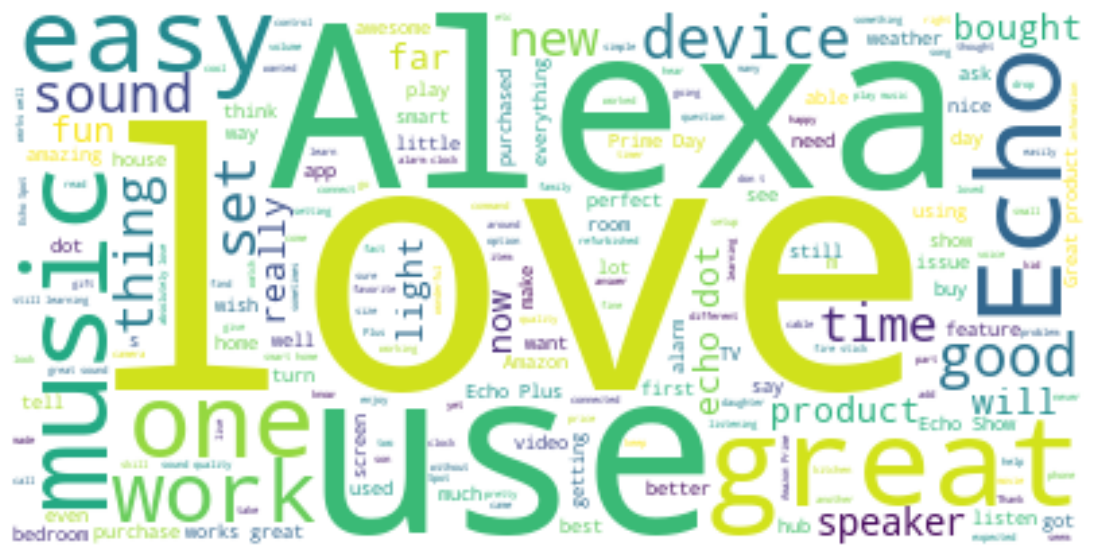

In [28]:
pos = d2.loc[d2.feedback=="Positive"].verified_reviews
text = " ".join(feedback for feedback in pos.astype(str))

generate_wcloud(text)

NEGATIVE WORDCLOUD

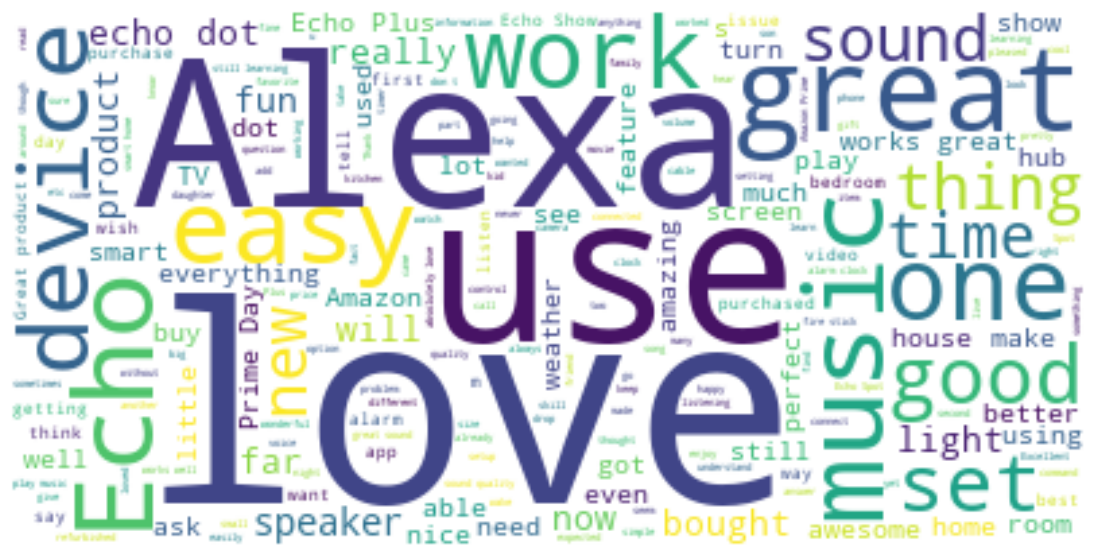

In [29]:
Neg = d2.loc[d2.feedback=="Negative"].verified_reviews
text = " ".join(feedback for feedback in pos.astype(str))

generate_wcloud(text)

NEUTRAL WORDCLOUD

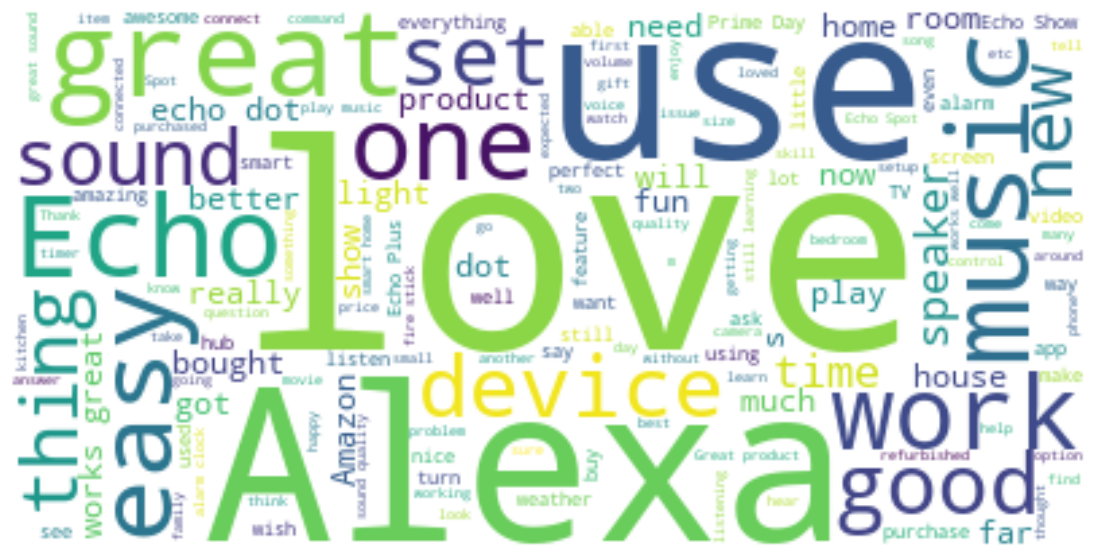

In [30]:
Neut = d2.loc[d2.feedback=="Neutral"].verified_reviews
text = " ".join(feedback for feedback in pos.astype(str))

generate_wcloud(text)

SPLITING THE DATA INTO TRAINING AND TESTING

In [31]:
x = d2.verified_reviews
y = d2.feedback

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.20, random_state=1, stratify=y)

In [32]:
x_train.shape,x_test.shape

((1852,), (463,))

In [33]:
x_train = x_train.fillna('')

In [34]:
x_train = x_train.fillna('').astype(str)

COUNTVECTORIZER

In [35]:
cv=CountVectorizer(max_features=10000)
cv.fit(x_train)

#transform
cv_x_train = cv.transform(x_train)
cv_x_test = cv.transform(x_test)

In [36]:
cv_x_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 39151 stored elements and shape (1852, 3691)>

In [37]:
#TfidVectorizer

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [59]:
tfidf = TfidfVectorizer(max_features=10000)
tfidf.fit(x_train)

#transform
tfidf_x_train = tfidf.transform(x_train)
tfidf_x_test = tfidf.transform(x_test)

In [40]:
tfidf_x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 39151 stored elements and shape (1852, 3691)>

LABEL ENCODER

In [41]:
labelencoder = LabelEncoder()

y_train = labelencoder.fit_transform(y_train)
y_test = labelencoder.transform(y_test)

labels = labelencoder.classes_.tolist()
print(labels)

['Negative', 'Neutral', 'Positive']


MODEL TRAINING AND EVALUATION

In [42]:
def train_and_eval(model, trainX, trainY, testX, testY):
    #training
    model.fit(trainX, trainY)

    #prediction
    ypre_train = model.predict(trainX)
    ypre_test = model.predict(testX)

    #evaluation AND ACCURACY
    print()
    print(model)
    print(f"Training accuracy score : {accuracy_score(y_train, ypre_train)}")
    print(f"Testing accuracy score : {accuracy_score(y_test, ypre_test)}")
    print('\n',40*'-')


LOGISTIC REGRESSION : with HYPERPARAMETER AND COUNTVECTORIZER

In [43]:
#HYPERPARAMETER
C = [0.001, 0.01, 0.1, 1, 10]

for c in C:
    #DEfine model
    model_lo = LogisticRegression(C=c, max_iter=500, random_state=1)

    #Train and evaluate model
    train_and_eval(model=model_lo,
                  trainX=cv_x_train,
                  trainY=y_train,
                  testX=cv_x_test,
                  testY=y_test)


LogisticRegression(C=0.001, max_iter=500, random_state=1)
Training accuracy score : 0.8644708423326134
Testing accuracy score : 0.8639308855291576

 ----------------------------------------

LogisticRegression(C=0.01, max_iter=500, random_state=1)
Training accuracy score : 0.8806695464362851
Testing accuracy score : 0.8639308855291576

 ----------------------------------------

LogisticRegression(C=0.1, max_iter=500, random_state=1)
Training accuracy score : 0.9341252699784017
Testing accuracy score : 0.8833693304535637

 ----------------------------------------

LogisticRegression(C=1, max_iter=500, random_state=1)
Training accuracy score : 0.9865010799136069
Testing accuracy score : 0.9006479481641468

 ----------------------------------------

LogisticRegression(C=10, max_iter=500, random_state=1)
Training accuracy score : 0.9973002159827213
Testing accuracy score : 0.9049676025917927

 ----------------------------------------


NAIVE-BAYES MODEL: HPERPARAMETER AND COUNTVECTORIZER

In [44]:
alphas = [0, 0.2, 0.6, 0.8, 1]

for a in alphas:
    #Define model
    model_nb = MultinomialNB(alpha=a)

    #Train and evaluate model
    train_and_eval(model=model_nb,
                  trainX=cv_x_train,
                  trainY=y_train,
                  testX=cv_x_test,
                  testY=y_test)


MultinomialNB(alpha=0)
Training accuracy score : 0.9778617710583153
Testing accuracy score : 0.8207343412526998

 ----------------------------------------

MultinomialNB(alpha=0.2)
Training accuracy score : 0.9703023758099352
Testing accuracy score : 0.8941684665226782

 ----------------------------------------

MultinomialNB(alpha=0.6)
Training accuracy score : 0.9562634989200864
Testing accuracy score : 0.8898488120950324

 ----------------------------------------

MultinomialNB(alpha=0.8)
Training accuracy score : 0.9497840172786177
Testing accuracy score : 0.8898488120950324

 ----------------------------------------

MultinomialNB(alpha=1)
Training accuracy score : 0.9357451403887689
Testing accuracy score : 0.8790496760259179

 ----------------------------------------


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\naive_bayes.py:898: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(


LOGISTIC REGRESSION: WITH HYPERPARAMETER AND TFIDF_VECTORIZER

In [45]:
#HYPERPARAMETER
C = [0.001, 0.01, 0.1, 1, 10]

for c in C:
    #DEfine model
    model_lo = LogisticRegression(C=c, max_iter=500, random_state=1)

    #Train and evaluate model
    train_and_eval(model=model_lo,
                  trainX=tfidf_x_train,
                  trainY=y_train,
                  testX=tfidf_x_test,
                  testY=y_test)


LogisticRegression(C=0.001, max_iter=500, random_state=1)
Training accuracy score : 0.8639308855291576
Testing accuracy score : 0.8639308855291576

 ----------------------------------------

LogisticRegression(C=0.01, max_iter=500, random_state=1)
Training accuracy score : 0.8639308855291576
Testing accuracy score : 0.8639308855291576

 ----------------------------------------

LogisticRegression(C=0.1, max_iter=500, random_state=1)
Training accuracy score : 0.8639308855291576
Testing accuracy score : 0.8639308855291576

 ----------------------------------------

LogisticRegression(C=1, max_iter=500, random_state=1)
Training accuracy score : 0.8952483801295896
Testing accuracy score : 0.8704103671706264

 ----------------------------------------

LogisticRegression(C=10, max_iter=500, random_state=1)
Training accuracy score : 0.9973002159827213
Testing accuracy score : 0.8898488120950324

 ----------------------------------------


NAIVE-BAYES MODEL: HPERPARAMETER AND TFIDF_VECTORIZER

In [46]:
alphas = [0, 0.2, 0.6, 0.8, 1]

for a in alphas:
    #Define model
    model_nb = MultinomialNB(alpha=a)

    #Train and evaluate model
    train_and_eval(model=model_nb,
                  trainX=tfidf_x_train,
                  trainY=y_train,
                  testX=tfidf_x_test,
                  testY=y_test)


MultinomialNB(alpha=0)
Training accuracy score : 0.9800215982721382
Testing accuracy score : 0.8207343412526998

 ----------------------------------------

MultinomialNB(alpha=0.2)
Training accuracy score : 0.908207343412527
Testing accuracy score : 0.8682505399568035

 ----------------------------------------

MultinomialNB(alpha=0.6)
Training accuracy score : 0.8650107991360692
Testing accuracy score : 0.8639308855291576

 ----------------------------------------

MultinomialNB(alpha=0.8)
Training accuracy score : 0.8644708423326134
Testing accuracy score : 0.8639308855291576

 ----------------------------------------

MultinomialNB(alpha=1)
Training accuracy score : 0.8644708423326134
Testing accuracy score : 0.8639308855291576

 ----------------------------------------


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\naive_bayes.py:898: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(


BEST MODEL: LOGISTIC REGRESSION(C=1) WITH tfid data

In [47]:
model = LogisticRegression(C=1, max_iter=500, random_state=1)
model.fit(tfidf_x_train,y_train)

LogisticRegression(C=1, max_iter=500, random_state=1)

In [48]:
#prediction
ypre_train = model.predict(tfidf_x_train)
ypre_test = model.predict(tfidf_x_test)

In [49]:
print(f"Train accuracy score: {accuracy_score(y_train, ypre_train)}")
print(f"Test accuracy score: {accuracy_score(y_test, ypre_test)}")


Train accuracy score: 0.8952483801295896
Test accuracy score: 0.8704103671706264


CONFUSION MATRIX

In [50]:
def plot_cm(y_true,ypre):
    plt.figure(figsize=(6,6))

    cm = confusion_matrix(y_true, ypre, normalize='true')

    sns.heatmap(cm, annot=True, cmap='Blues', cbar=False, fmt='.2f',
               xticklabels=labels, yticklabels=labels)

    return plt.show()

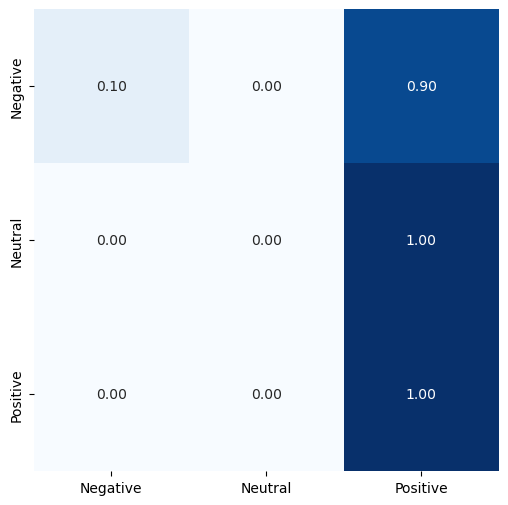

In [51]:
plot_cm(y_test, ypre_test)

In [52]:
#save model and transformer

In [53]:
import pickle

In [54]:
with open("Models/model.pkl", "wb") as f:
    pickle.dump(model_lo, f)

with open("Models/tfidfvectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("Models/labelencoder.pkl", "wb") as f:
    pickle.dump(labelencoder, f)

prediction on single review

In [55]:
#Labels = ['Negative', 'Neutral', 'Positive']
def get_sentiment(feedback):
    #preprocessing
    x = TEXT_PREPROCESSOR(feedback)
    #vectorization
    x = tfidf.transform([x])
    #prediction
    y = int(model.predict(x.reshape(1,-1)))
    return labels[y]

In [56]:
#positive feedback
feedback = "This chips packet is very tasty. I highly recommend this!"
print(f"This is a {get_sentiment(feedback)} feedback!")

This is a Positive feedback!


C:\Users\hp\AppData\Local\Temp\ipykernel_18584\301444921.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = int(model.predict(x.reshape(1,-1)))


In [57]:
#Negative feedback
feedback = "This product is a waste of money. Don't buy this!"
print(f"This is a {get_sentiment(feedback)} feedback!")

This is a Negative feedback!


C:\Users\hp\AppData\Local\Temp\ipykernel_18584\301444921.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = int(model.predict(x.reshape(1,-1)))
